<a href="https://colab.research.google.com/github/sabarehmann/Indian_Kids_Screentime_ml/blob/main/Indian_Kids_Screentime_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, math
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
df.columns = df.columns.str.strip().str.lower()   # normalize col names
df.head()

,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
# ------------------------------
# Step 3: Keep Relevant Columns
# ------------------------------
# Map actual column names to standard names
col_map = {
    'age': 'age',
    'gender': 'gender',
    'avg_daily_screen_time_hr': 'avg_daily_screen_time_hr',
    'primary_device': 'primary_device',
    'exceeded_recommended_limit': 'exceeded_recommended_limit',
    'educational_to_recreational_ratio': 'educational_to_recreational_ratio',
    'health_impacts': 'health_impacts',
    'urban_or_rural': 'urban_or_rural'
}
df = df.rename(columns=col_map)

# Keep relevant ones
df = df[list(col_map.values())].copy()

# Convert numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['avg_daily_screen_time_hr'] = pd.to_numeric(df['avg_daily_screen_time_hr'], errors='coerce')
df['educational_to_recreational_ratio'] = pd.to_numeric(df['educational_to_recreational_ratio'], errors='coerce')

# Convert exceeded_recommended_limit to 0/1
tmp = df['exceeded_recommended_limit'].astype(str).str.strip().str.lower()
tmp = tmp.replace({'true':1, 'false':0, 'yes':1, 'no':0, 'y':1, 'n':0, '1':1, '0':0})
tmp = pd.to_numeric(tmp, errors='coerce').fillna(0).astype(int)
df['exceeded_recommended_limit'] = tmp

# Drop rows without target
df = df.dropna(subset=['avg_daily_screen_time_hr']).reset_index(drop=True)

print("Final dataframe shape:", df.shape)
df.head()

Final dataframe shape: (9712, 8)


,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural
0,14,Male,3.99,Smartphone,1,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,1,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,1,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,0,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,1,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
X = df[['age','gender','primary_device','exceeded_recommended_limit',
        'educational_to_recreational_ratio','health_impacts','urban_or_rural']]
y = df['avg_daily_screen_time_hr']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
cat_features = ['gender','primary_device','health_impacts','urban_or_rural']
num_features = ['age','educational_to_recreational_ratio','exceeded_recommended_limit']

preprocess = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features),

    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_features)
])

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}


LinearRegression:
 RMSE=1.27 | MAE=0.99 | R²=0.44


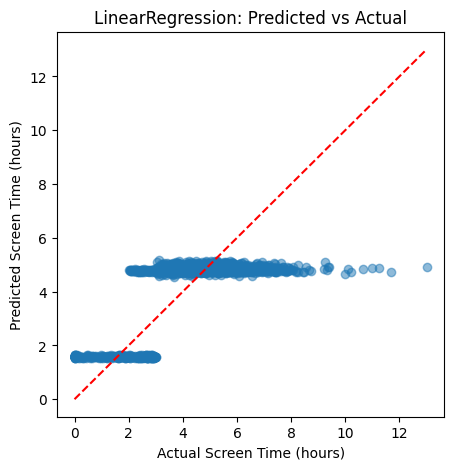


RandomForest:
 RMSE=1.37 | MAE=1.03 | R²=0.35


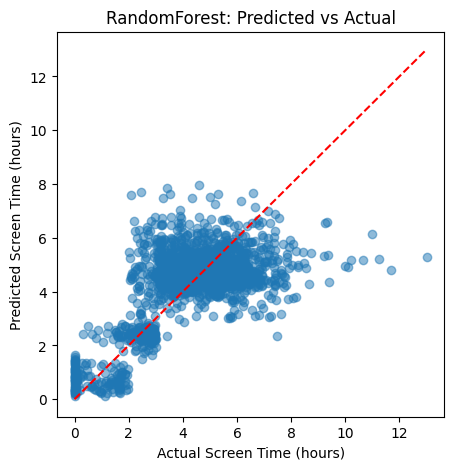


GradientBoosting:
 RMSE=1.22 | MAE=0.94 | R²=0.48


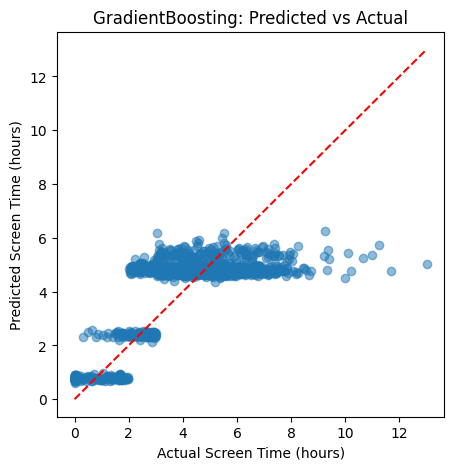

In [ ]:
results = {}
for name, model in models.items():
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = (rmse, mae, r2)

    print(f"\n{name}:\n RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.2f}")

    # Scatter plot
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],"r--")
    plt.xlabel("Actual Screen Time (hours)")
    plt.ylabel("Predicted Screen Time (hours)")
    plt.title(f"{name}: Predicted vs Actual")
    plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# State
state = {"pipe": None, "name": None}

# Dropdown for model
model_dd = widgets.Dropdown(
    options=list(models.keys()),
    value="RandomForest",
    description="Model:"
)

# Inputs
age_in   = widgets.IntText(value=12, description="Age:")
gender_in= widgets.Text(value="Male", description="Gender:")
device_in= widgets.Text(value="Smartphone", description="Device:")
exceed_in= widgets.IntText(value=1, description="Exceeded Limit (0/1):")
ratio_in = widgets.FloatText(value=0.4, description="Edu/Recr Ratio:")
health_in= widgets.Text(value="Poor Sleep", description="Health Impacts:")
urban_in = widgets.Text(value="Urban", description="Urban/Rural:")

train_btn = widgets.Button(description="(Re)Train", button_style="primary")
pred_btn  = widgets.Button(description="Predict", button_style="success")
out       = widgets.Output(layout={'border': '1px solid #ddd', 'padding':'8px'})

# --- Train handler ---
def on_train_clicked(_):
    with out:
        clear_output(wait=True)
        name = model_dd.value
        model = models[name]
        pipe = Pipeline([("pre", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)
        state["pipe"], state["name"] = pipe, name
        print(f"✅ Trained {name}")

# --- Predict handler ---
def on_predict_clicked(_):
    with out:
        if state["pipe"] is None:
            print("Train a model first.")
            return
        data = pd.DataFrame([{
            "age": age_in.value,
            "gender": gender_in.value,
            "primary_device": device_in.value,
            "exceeded_recommended_limit": exceed_in.value,
            "educational_to_recreational_ratio": ratio_in.value,
            "health_impacts": health_in.value,
            "urban_or_rural": urban_in.value
        }])
        pred = state["pipe"].predict(data)[0]
        print(f"Model: {state['name']} | Predicted Screen Time: {pred:.2f} hours")

train_btn.on_click(on_train_clicked)
pred_btn.on_click(on_predict_clicked)

# --- Layout ---
ui = widgets.VBox([
    widgets.HBox([model_dd, train_btn]),
    age_in, gender_in, device_in, exceed_in, ratio_in, health_in, urban_in,
    pred_btn, out
])

display(ui)